<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/12_training_and_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training and Validation

When training a neural network, we do not use the entire dataset for learning.

The dataset is divided into:

- Training Data
- Validation Data

The model learns from the training data.

The validation data is never used to update the weights. Instead, it helps us measure how well the model generalizes to unseen data during training.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))

Training Samples: 6
Validation Samples: 2


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.7601 - val_accuracy: 1.0000 - val_loss: 0.5078
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step - accuracy: 0.6667 - loss: 0.7593 - val_accuracy: 1.0000 - val_loss: 0.5083
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.6667 - loss: 0.7585 - val_accuracy: 1.0000 - val_loss: 0.5089
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6667 - loss: 0.7576 - val_accuracy: 1.0000 - val_loss: 0.5094
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6667 - loss: 0.7568 - val_accuracy: 1.0000 - val_loss: 0.5100
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6667 - loss: 0.7560 - val_accuracy: 1.0000 - val_loss: 0.5106
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6667 - loss: 0.7552 - val_accuracy: 1.0000 - val_loss: 0.5111
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6667 - loss: 0.7543 - val_accuracy: 1.0000 - val_loss

In [7]:
loss, accuracy = model.evaluate(X_val, y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.5530
Validation Loss: 0.5530098080635071
Validation Accuracy: 1.0


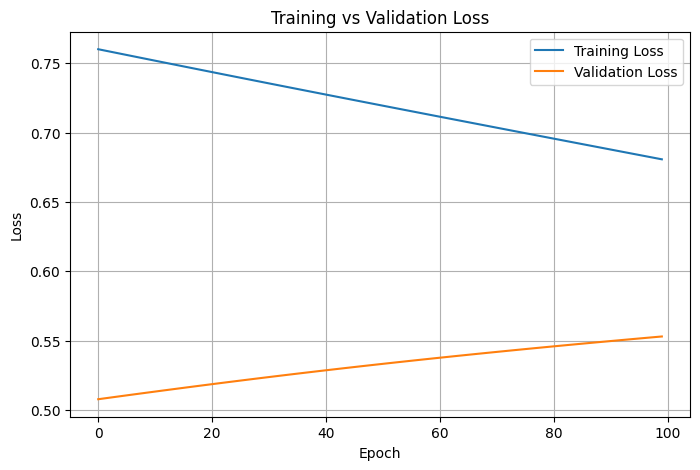

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

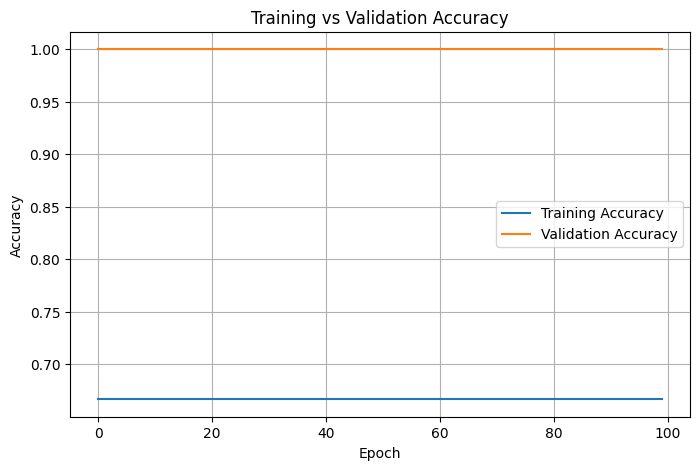

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [10]:
history.history

{'accuracy': [0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816

In [11]:
import pandas as pd

summary = pd.DataFrame({
    "Metric":[
        "Training Loss",
        "Validation Loss",
        "Training Accuracy",
        "Validation Accuracy"
    ],
    "Purpose":[
        "Measures learning on training data",
        "Measures generalization",
        "Training performance",
        "Performance on unseen data"
    ]
})

summary

,Metric,Purpose
0,Training Loss,Measures learning on training data
1,Validation Loss,Measures generalization
2,Training Accuracy,Training performance
3,Validation Accuracy,Performance on unseen data
